In [1]:
#Importing relevent packages
import sys; print(sys.executable)
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta

#Importing kernels file
import custom_kernels as ck

#SETTINGS
#Time-related settings
starttime = datetime(2024,8,1)
endtime = datetime(2024,10,1)
dtime_data = timedelta(days=1)    #je stelt hier handmatig in wat de tijdsresolutie is van je data #deze kan niet naar minuten (13/5/2025)
dtime_execute = timedelta(minutes=10)
simulation_days = 15    

#Selecting physical variables to add
add_stokes = True
avg_stokes = True
add_wind = True
add_tempcalc = True

#Output storing
output_folder = "/storage/shared/oceanparcels/output_data/data_Elena/"
output_file_name = "Physical_check_adv_st_wi.zarr"

##################################################################################################
#Loading the physical dataset and matching the grid
directory_phy =  '/storage/shared/oceanparcels/input_data/MOi/'
phy_base_file =  directory_phy + 'GLO12/psy4v3r1-daily_{vector:s}_{y:04d}-{m:02d}-{d:02d}.nc' 
phy_files_U = []
phy_files_V = []
phy_files_T = []

time = starttime
phy_file_W = directory_phy + 'GLO12/psy4v3r1-daily_{vector:s}_{y:04d}-{m:02d}-{d:02d}.nc'.format(vector = 'W', y = time.year, m = time.month, d = time.day)
while(time < endtime):
    phy_files_U.append(phy_base_file.format(vector = 'U', y = time.year, m = time.month, d = time.day))
    phy_files_V.append(phy_base_file.format(vector = 'V', y = time.year, m = time.month, d = time.day))
    phy_files_T.append(phy_base_file.format(vector = 'T', y = time.year, m = time.month, d = time.day))
    time+=dtime_data

#print(phy_files_U)

mesh_file_h = directory_phy + "domain_ORCA0083-N006/PSY4V3R1_mesh_hgr.nc"   #Hiermee converteren we het grid!
mesh_file_z = directory_phy + "domain_ORCA0083-N006/PSY4V3R1_mesh_zgr.nc"
filenames_phy = {'U': {
        'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_U,
    }, 'V': {
        'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_V,
    }, 'T': {'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_T,
    }
}
variables_phy = {'U': 'vozocrtx',
                'V': 'vomecrty',
                'T': 'votemper'}

c_grid_dimensions = {   'lat': 'gphif',
                        'lon': 'glamf',
                        'depth':'depthw',
                        'time': 'time_counter'}

dimensions_phy = {'U': c_grid_dimensions,
                 'V': c_grid_dimensions,
                 'T': c_grid_dimensions}

#Defining a range of indices to load as fieldset to reduce computational time
indices = {'lat': range(800,2000),
           'lon': range(2300,3500)
           }

#Creating fieldset
fieldset = parcels.FieldSet.from_nemo(filenames=filenames_phy,variables=variables_phy,dimensions=dimensions_phy, indices=indices)
print('fieldset = made')

#Adding the wave/stokes data
if avg_stokes:
    sarg_depth_extent = 1  

if add_stokes:
    directory_stokes = '/storage/shared/oceanparcels/input_data/CopernicusMarineService/GLOBAL_ANALYSISFORECAST_WAV_001_027/'
    stokes_base_file =  directory_stokes + 'cmems_mod_glo_wav_anfc_0.083deg_PT3H-i_VSDX-VSDY-VTPK_180.00W-179.92E_80.00S-90.00N_{y:04d}-{m:02d}-{d:02d}-{y:04d}-{m:02d}-{d:02d}.nc' 
    stokes_base_file =  directory_stokes + 'cmems_mod_glo_wav_anfc_0.083deg_PT3H-i_VSDX-VSDY-VTPK_180.00W-179.92E_80.00S-90.00N_{y:04d}-{m:02d}-{d:02d}-{y:04d}-{m:02d}-{d:02d}.nc'
    
    stokes_files = []

    time = starttime
    while(time < endtime):
        stokes_files.append(stokes_base_file.format(y = time.year, m = time.month, d = time.day ))
        time+=dtime_data

    #print(stokes_files)
    
    filenames_stokes = {'U_wave_Stokes': stokes_files,
                    'V_wave_Stokes': stokes_files,
                    'wave_Tp': stokes_files,
                    }
    variables_stokes = {'U_wave_Stokes': 'VSDX',        #Sea surface wave stokes drift x velocity
                    'V_wave_Stokes': 'VSDY',            #Sea surface wave stokes drift y velocity
                    'wave_Tp': 'VTPK'                   #Wave peak period
                    }
    dimensions_stokes = {'lat': 'latitude',
                        'lon': 'longitude',
                        'time': 'time'}
    
    #Defining a range of indices to load as fieldset to reduce computational time
    indices_stokes = {'lat': range(650,1750),
                       'lon': range(800,2500)
                     } 
    
    fieldset_stokes = parcels.FieldSet.from_netcdf(filenames=filenames_stokes, variables=variables_stokes, dimensions=dimensions_stokes, indices=indices_stokes)

    #Converting units
    fieldset_stokes.U_wave_Stokes.units = parcels.tools.converters.GeographicPolar()
    fieldset_stokes.V_wave_Stokes.units = parcels.tools.converters.Geographic()

    #Adding fields to initial fields
    fieldset.add_field(fieldset_stokes.U_wave_Stokes)
    fieldset.add_field(fieldset_stokes.V_wave_Stokes)

    #Only required if more advanced Stokes drift is implemented
    if avg_stokes:
        fieldset.add_field(fieldset_stokes.wave_Tp)
        fieldset.add_constant('G', 9.81)  # Gravitational constant [m s-1]
        fieldset.add_constant('depth_extent', sarg_depth_extent)  # depth extent of the sargassum [in m]

if add_wind:

    ds = xr.open_mfdataset('/storage/shared/oceanparcels/input_data/ERA5/reanalysis-era5-single-level_wind10m_2024*.nc')

    filenames_wind = ds.sel(valid_time=slice(starttime, endtime))

    variables_wind = {'U_wind': 'u10', 
                      'V_wind':'v10'}

    dimensions_wind = {'lon':'longitude', 
                       'lat': 'latitude', 
                       'time': 'valid_time'}

    fieldset_wind= parcels.FieldSet.from_xarray_dataset(filenames_wind, variables_wind, dimensions_wind, mesh='spherical')

    fieldset_wind.add_periodic_halo(zonal=True)

    windage_factor = 0.01

    fieldset_wind.U_wind.set_scaling_factor(windage_factor)
    fieldset_wind.V_wind.set_scaling_factor(windage_factor)

    fieldset_wind.U_wind.units = parcels.tools.converters.GeographicPolar()
    fieldset_wind.V_wind.units = parcels.tools.converters.Geographic()

    fieldset.add_field(fieldset_wind.U_wind)
    fieldset.add_field(fieldset_wind.V_wind)

if add_tempcalc:
    #Overall average growth rate (Corbin & Oxenford)
    fieldset.add_constant('RGR_SF3', 0.077) 
    fieldset.add_constant('RGR_SN1', 0.046)
    fieldset.add_constant('RGR_SN8', 0.032)
    fieldset.add_constant('initial_weight', 50) #grams

/nethome/6903894/parcels_env/bin/python
fieldset = made


/nethome/6903894/parcels_env/lib/python3.13/site-packages/parcels/grid.py:563: FieldSetWarning: Flipping lat data from North-South to South-North. Note that this may lead to wrong sign for meridional velocity, so tread very carefully
  super().__init__(lon, lat, time, time_origin, mesh)
/nethome/6903894/parcels_env/lib/python3.13/site-packages/parcels/grid.py:563: FieldSetWarning: Flipping lat data from North-South to South-North. Note that this may lead to wrong sign for meridional velocity, so tread very carefully
  super().__init__(lon, lat, time, time_origin, mesh)


In [ ]:
print(len(fieldset.T.lon))
print(len(fieldset.T.lat))
print(np.shape(fieldset.T.data))

/tmp/ipykernel_5402/1953443344.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  pplot = ax.plot(pset.lon, pset.lat, "ko", color='darkblue')


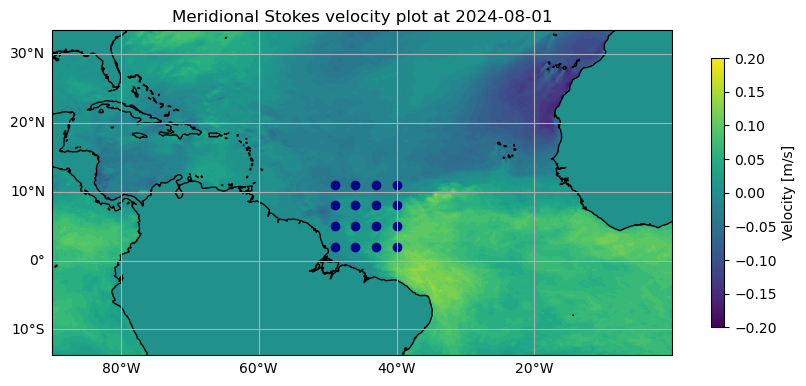

In [70]:
#By using fieldset.computeTimeChunk(), we load the first time frame of the fieldset.
fieldset.computeTimeChunk()

#Plotting velocity field of first timestep
fig1 = plt.figure(figsize = (10,7))
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset.U_wave_Stokes.lon, fieldset.U_wave_Stokes.lat, fieldset.V_wave_Stokes.data[0,:,:], 
               vmin = -0.2, vmax = 0.2, transform=ccrs.PlateCarree())
pplot = ax.plot(pset.lon, pset.lat, "ko", color='darkblue')
ax.add_feature(cartopy.feature.COASTLINE.with_scale('50m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Meridional Stokes velocity plot at {starttime.date()}')
ax.set_extent([-90,0,-10,25])
cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5)
cbar.set_label('Velocity [m/s]')
plt.show()

In [68]:
# #Defining particle set that we can advect on fieldset
nparticles = 16   #how many particles will be advected

sampling_variables = ['temperature', 'weight']

class SargassumParticle(parcels.JITParticle):
    temperature = parcels.Variable('temperature', dtype=np.float32, to_write=True, initial=0)
    weight = parcels.Variable('weight', dtype=np.float32, to_write=True, initial=50)

pset = parcels.ParticleSet.from_list(
     fieldset=fieldset,  # the fields on which the particles are advected
     #pclass=parcels.JITParticle.add_variables(sampling_variables),  # the type of particles (JITParticle or ScipyParticle)
     pclass = SargassumParticle,
     lon=[-40, -40, -40, -40, -43, -43, -43, -43 , -46, -46, -46, -46, -49, - 49, -49, -49], # a vector of release longitudes
     lat=[2,  5,  8, 11, 2, 5,  8, 11, 2, 5,  8,11, 2, 5,  8, 11],                # a vector of release latitudes
     depth=[0] * nparticles                              # a vector of release depths
 )

#Defining particle set that we can advect on fieldset
# nparticles = 8   #how many particles will be advected

# sampling_variables = ['temperature', 'weight']

# class SargassumParticle(parcels.JITParticle):
#     temperature = parcels.Variable('temperature', dtype=np.float32, to_write=True, initial=0)
#     weight = parcels.Variable('weight', dtype=np.float32, to_write=True, initial=50)

# pset = parcels.ParticleSet.from_list(
#      fieldset=fieldset,  # the fields on which the particles are advected
#      #pclass=parcels.JITParticle.add_variables(sampling_variables),  # the type of particles (JITParticle or ScipyParticle)
#      pclass = SargassumParticle,
#      lon=[-46, -46, -46, -46, -49, - 49, -49, -49], # a vector of release longitudes
#      lat=[ 2, 5,  8,11, 2, 5,  8, 11],                # a vector of release latitudes
#      depth=[0] * nparticles                              # a vector of release depths
#  )


In [16]:
def sampleT(particle, fieldset, time):
    particle.temperature = fieldset.T[time, particle.depth, particle.lat, particle.lon]

def growth_temp_based(particle, fieldset, time):

    #Model parameters based on Jouanno et al. (2021) in deg Celsius
    T_opt_J = 26
    Tmin_J = 10.5
    Tmax_J = 43.8
    #Growth limitation dependent on temperature, formula from Jouanno et al. (2021).
    if particle.temperature < T_opt_J:
        limitation_factor = math.exp(-0.5 * ( (particle.temperature - T_opt_J)/ (Tmin_J - particle.temperature))**2 )
    else:
        limitation_factor = math.exp(-0.5 * ( (particle.temperature - T_opt_J)/ (Tmax_J - particle.temperature))**2 )

    #Update particle weight with doubling rate converted from day-1 to s-1
    particle.weight += limitation_factor * (fieldset.RGR_SF3 / (24*60*60)) * particle.dt
  


output_file = pset.ParticleFile(
    name=  output_folder + output_file_name, # the file name
    outputdt=timedelta(hours=2),             # the time step of the outputs
    chunks = (nparticles, 50))               #per hoeveel tijdstappen je data wordt opgeslagen

#Selecting kernels with parcels.AdvectionRK4 as default
kernels = [ parcels.AdvectionRK4 ]

if add_stokes:
    if avg_stokes:
        kernels+= [ck.avg_Stokes_drift]
    else:
        kernels+= [ck.direct_Stokes_drift]
if add_wind:
    kernels+= [ck.wind_drag]
if add_tempcalc:
    kernels+= [sampleT, growth_temp_based]

#Executing
pset.execute(
    kernels,                                    # the kernels (which define how particles move)
    runtime=timedelta(days=simulation_days),    # the total length of the run
    dt=dtime_execute,                                   # the timestep of the kernel
    output_file=output_file,
)

INFO: Output files are stored in /storage/shared/oceanparcels/output_data/data_Elena/Physical_check_adv_st_wi.zarr.
100%|██████████| 1296000.0/1296000.0 [05:31<00:00, 3908.62it/s]


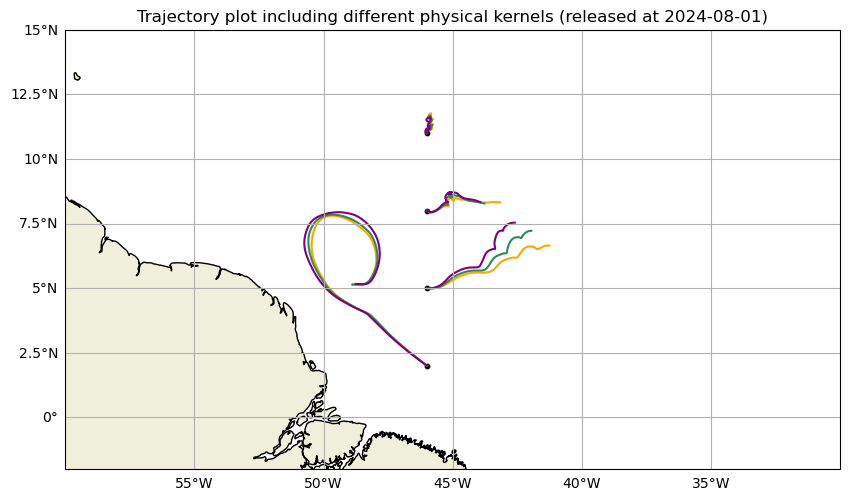

In [ ]:
DSadv = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Physical_check_adv.zarr")
DSst =  xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Physical_check_adv_st.zarr")
DSwi =  xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Physical_check_adv_st_wi.zarr")

#print(DS20)

figcheck = plt.figure(figsize = (10,7))
ax = plt.axes(projection=ccrs.PlateCarree())
#Release locations
pplot = ax.scatter(DSadv.lon, DSadv.lat[:4,0], s = 10 ,color='black') #Transposing lon and lat arrays!
#Trajectories
tplot = ax.plot(DS9.lon.T, DS9.lat.T, "-", color= 'orange') #Transposing lon and lat arrays!
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Trajectory plot including different physical kernels (released at {starttime.date()})')
ax.set_extent([-60,-30,-2,15])
plt.show()

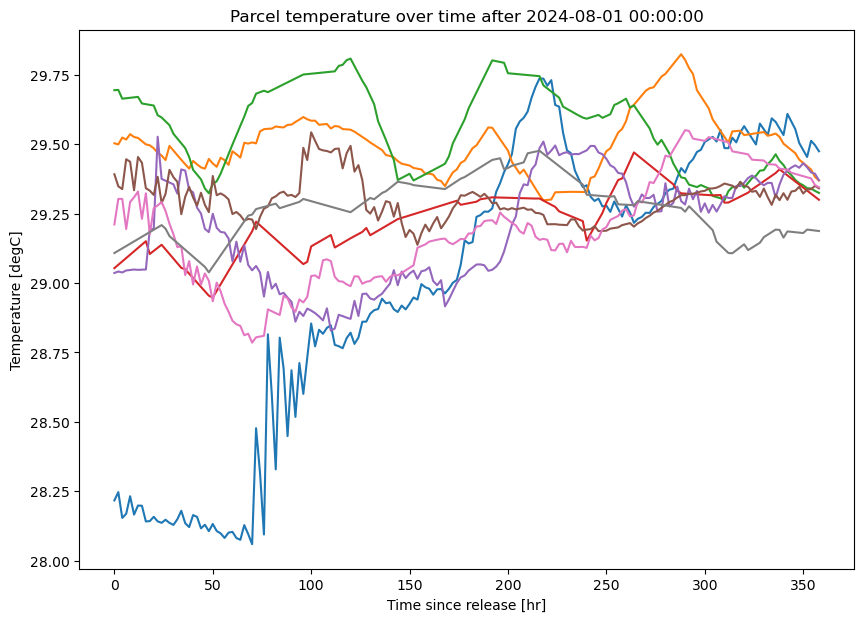

In [40]:
time_in_hours = ((DSadv['time']-DSadv['time'][:,0]).astype("timedelta64[h]"))

figtemp = plt.figure(figsize = (10,7))
plt.plot(time_in_hours.transpose(), DSadv.temperature.transpose() )
plt.title(f'Parcel temperature over time after {starttime}')
plt.xlabel('Time since release [hr]')
plt.ylabel('Temperature [degC]')
plt.show()

In [ ]:
import calculate_distance as cd
x = DSadv["lon"][:4,:].values
y = DSadv["lat"][:4,:].values

xs = DSst["lon"][:4,:].values
ys = DSst["lat"][:4,:].values

xw = DSwi["lon"][:4,:].values
yw = DSwi["lat"][:4,:].values

dxs = xs - x
dys = ys - y

dxw = xw - x
dyw = yw - y

distance = np.cumsum( np.sqrt(np.square(np.diff(x)) + np.square(np.diff(y))), axis=1)  # d = (dx^2 + dy^2)^(1/2)
rel_dist = np.cumsum( np.sqrt(np.square(np.diff(dxs)) + np.square(np.diff(dys))), axis=1)
rel_dist_w = np.cumsum( np.sqrt(np.square(np.diff(dxw)) + np.square(np.diff(dyw))), axis=1)

s = cd.cumulative_distance_01(DSadv)
s_s = cd.cumulative_distance_01(DSst)
s_w = cd.cumulative_distance_01(DSwi)

print(np.shape(x), np.shape(xs), np.shape(dxs), np.shape(rel_dist))

(4, 200) (4, 200) (4, 200) (4, 199)


(4, 200)


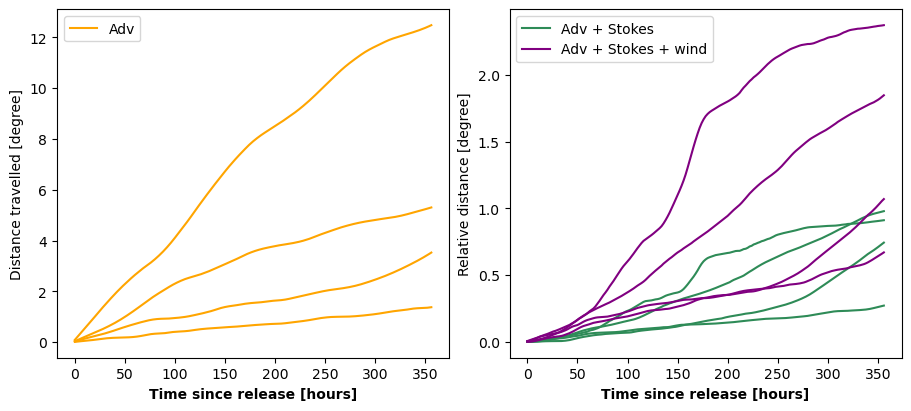

In [80]:
time_in_hours = ((DSadv['time'][:4,:]-DSadv['time'][:4,0]).astype("timedelta64[h]"))
time_in_hours_ = (DSadv['time'].astype("timedelta64[h]"))
secy = np.zeros_like(time_in_hours)

print(np.shape(time_in_hours))

#Plotting distance against time that the parcels travelled
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

ax1.set_ylabel("Distance travelled [degree]")
ax1.set_xlabel("Time since release [hours]", weight="bold")
d_plot = ax1.plot(time_in_hours[:1,:-1].transpose(), distance[:1,:].transpose(), color = 'orange', label = 'Adv')
d_plot = ax1.plot(time_in_hours[1:,:-1].transpose(), distance[1:,:].transpose(), color = 'orange')
ax1.legend()

ax2.set_ylabel("Relative distance [degree]")
ax2.set_xlabel("Time since release [hours]", weight="bold")
#d_plot_t = ax2.plot( cumulative_distances_km[:,:-10].transpose())
d_plot_t = ax2.plot(time_in_hours[:1,:-1].transpose(), rel_dist[:1,:].transpose(), color='seagreen', label = 'Adv + Stokes')
d_plot_t = ax2.plot(time_in_hours[:1,:-1].transpose(),rel_dist_w[:1,:].transpose(), color='purple', label = 'Adv + Stokes + wind')
d_plot_t = ax2.plot(time_in_hours[1:,:-1].transpose(),rel_dist[1:,:].transpose(), color='seagreen')
d_plot_t = ax2.plot(time_in_hours[1:,:-1].transpose(),rel_dist_w[1:,:].transpose(), color='purple')
ax2.legend()
#ax2.set_xlim(0,720)
#ax2b = ax2.twiny()
#secy_plot = ax2b.plot(time_in_hours[0:2,:-10].transpose()/24, secy[0:2,:-10].transpose(), c='w')
#ax2b.set_xlabel("Time since release [days]", weight="bold")
plt.show()